## Run DOLPHOT on simulated Rosesim images and do artificial star injection tests

In [1]:
# Import packages
%load_ext autoreload
%autoreload 2

import matplotlib
from matplotlib import pyplot as plt
import numpy as np
import os
from astropy.io import fits
from kuaizi.display import display_single

import romanisim
import romanisim.parameters
import romanisim.bandpass
from astropy.table import Table, hstack, vstack
import astropy.units as u
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord

import sys
sys.path.append('/home/jiaxuanl/Research/SALAD/script/')
sys.path.append('/home/jiaxuanl/Research/Roman_Cycle1/')
from display import show_image_wcs

from scipy.stats import binned_statistic
import kuaizi
kuaizi.set_matplotlib(style='nature', usetex=False, dpi=90)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
import ripples

2026-02-25 14:21:44 INFO     Note: NumExpr detected 64 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 16.


2026-02-25 14:21:44 INFO     NumExpr defaulting to 16 threads.


## 1. Check DOLPHOT residuals

In [3]:
exptime = 600
host = 'sky_jaguar_trilegal_cena'
# host = 'cena'

In [4]:
os.chdir(f'/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/DOLPHOT/{host}/')
!pwd

/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/DOLPHOT/dw1e6


/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/DOLPHOT/sky_jaguar_trilegal_n253


/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/DOLPHOT/sky_jaguar_trilegal_cena


/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/DOLPHOT/sky_jaguar_trilegal_cena


(<Figure size 900x360 with 2 Axes>,
 <Axes: >,
 {'norm': <astropy.visualization.mpl_normalize.ImageNormalize at 0x7efe6de269e0>})

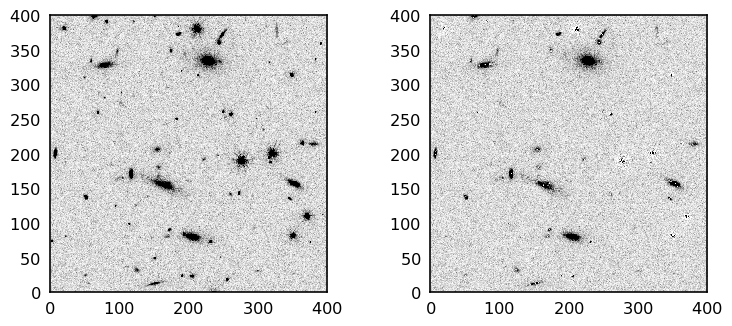

(<Figure size 900x360 with 2 Axes>,
 <Axes: >,
 {'norm': <astropy.visualization.mpl_normalize.ImageNormalize at 0x7ff8fe33f620>})

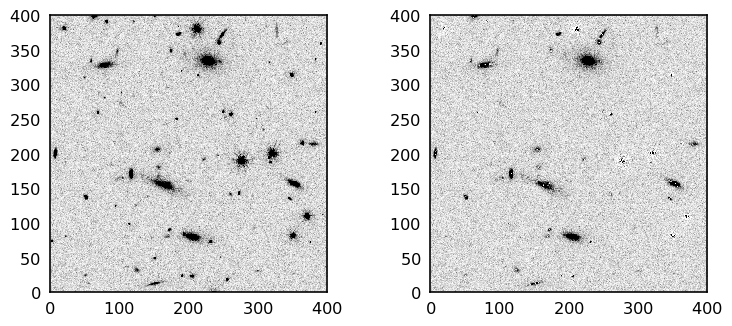

In [5]:
fig, [ax1, ax2] = plt.subplots(1, 2, figsize=(10, 4))

hdu = fits.open(f'./F106_600s_LINEGAP5_1.0.fits')
_, _, norm = show_image_wcs(hdu[0].data[300:700,300:700], fig=fig, ax=ax1, percl=99)
w = WCS(hdu[0].header)

exptime = 3000
# The residual image after DOLPHOT. You'll see lots of point sources disappear.
# hdu = fits.open(f'./{host}_{exptime}s/{host}_{exptime}s.phot.1.res.fits')
hdu = fits.open(f'./{host}_{exptime}s/{host}_3000s.phot.1.res.fits')
show_image_wcs(hdu[0].data[300:700,300:700], fig=fig, ax=ax2, scale_args=norm)

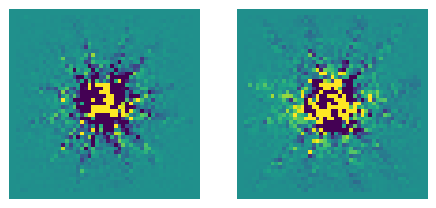

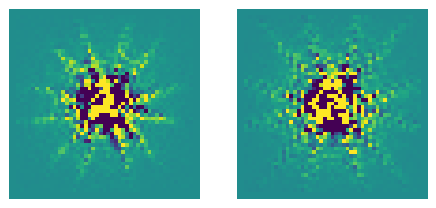

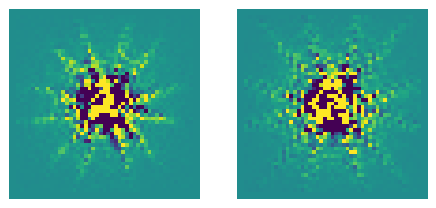

In [6]:
# This shows the "correction" term to the fiducial Roman PSF templates, as we downloaded when installing DOLPHOT
exptime = 3000
fig, [ax1, ax2] = plt.subplots(1, 2, figsize=(6, 3))
hdu = fits.open(f'./{host}_{exptime}s/{host}_{exptime}s.phot.1.psf.fits')
display_single(hdu[0].data, xsize=4, ysize=4, scale_bar=False, ax=ax1);
hdu = fits.open(f'./{host}_{exptime}s/{host}_{exptime}s.phot.10.psf.fits')
display_single(hdu[0].data, xsize=4, ysize=4, scale_bar=False, ax=ax2);

## 2. Check the DOLPHOT catalog

In [7]:
from rosesim.utils import read_dolphot_cat, xmatch_true_meas
from rosesim import Roman_zp_AB_Vega_parsec

def quality_cut(cat, snr=5, crowd={'f158': 0.5, 'f106': 0.5}, sharp={'f158': 0.03, 'f106': 0.03}):
    flag = cat['snr_f158'] > snr
    flag &= cat['snr_f106'] > snr
    flag &= (cat['crowd_f106'] < crowd['f106'])
    flag &= (cat['crowd_f158'] < crowd['f158'])
    flag &= (cat['qflag_f158'] <= 4)
    flag &= (cat['qflag_f106'] <= 4)
    flag &= (cat['obj_type'] <= 2) # (1=bright star, 2=faint, 3=elongated, 4=hot pixel, 5=extended)
    flag &= (cat['pass_det'] < 3)
    return flag


def point_source_cut(cat, snr=5, crowd={'f158': 0.5, 'f106': 0.5}, sharp={'f158': 0.03, 'f106': 0.03}):
    flag = quality_cut(cat, snr=snr, crowd=crowd, sharp=sharp)
    flag &= (cat['sharp_f106']**2 < sharp['f106'])
    flag &= (cat['sharp_f158']**2 < sharp['f158'])
    flag &= (cat['chi_f106'] < 3)
    flag &= (cat['chi_f158'] < 3)
    return flag

In [8]:
# plt.scatter(cat['mag_ab_f106'], cat['mag_ab_f106'] - cat['mag_vega_f106'])
# plt.ylim(-2, 2)

In [9]:
exptime = 3000
os.chdir(f'/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/DOLPHOT/{host}/')
cat = read_dolphot_cat(f'./{host}_{exptime}s/{host}_{exptime}s.phot', 
                       f'./{host}_{exptime}s/{host}_{exptime}s.phot.columns', fake=False)

Filters: ['F106', 'F158']


Filters: ['F106', 'F158']


Text(0, 0.5, 'sharp')

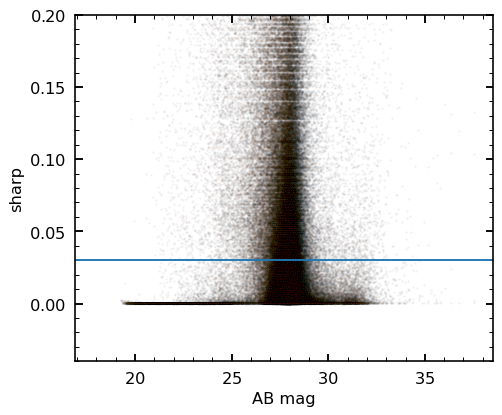

Text(0, 0.5, 'sharp')

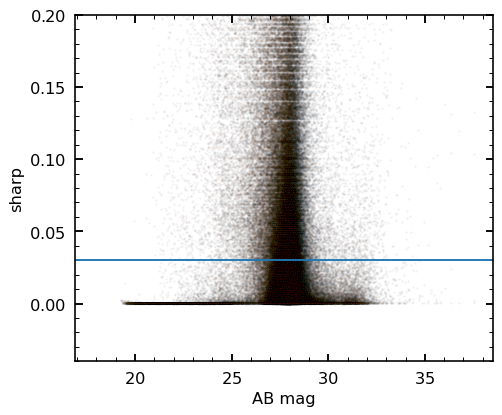

In [10]:
cat['ra'], cat['dec'] = w.all_pix2world(cat['x'], cat['y'], 1)

plt.scatter(cat['mag_ab_f106'], abs(cat['sharp_f106'])**2, s=1, alpha=0.04)
plt.scatter(cat['mag_ab_f158'], abs(cat['sharp_f158'])**2, s=1, alpha=0.04)
plt.ylim(-0.04, 0.2)
plt.axhline(0.03)
plt.xlabel('AB mag')
plt.ylabel('sharp')

In [133]:
# plt.scatter(cat['crowd_f106'], cat['crowd_f106'] - cat['crowd_f158'], s=3)
# plt.ylim(-1, 1)

Text(0, 0.5, 'crowd')

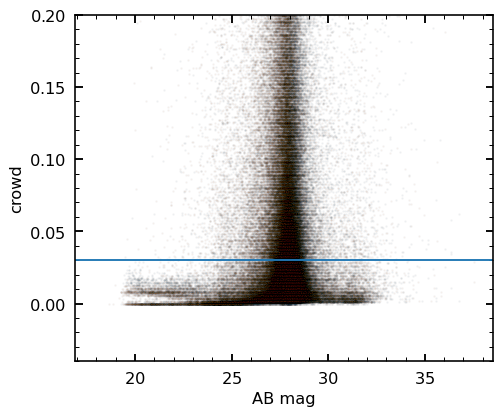

Text(0, 0.5, 'crowd')

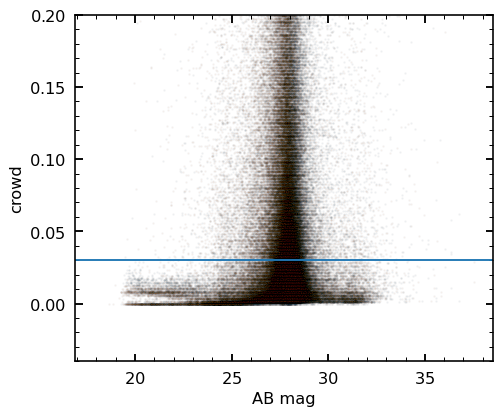

In [11]:
plt.scatter(cat['mag_ab_f106'], (cat['crowd_f106']), s=1, alpha=0.04)
plt.scatter(cat['mag_ab_f158'], (cat['crowd_f158']), s=1, alpha=0.04)
plt.ylim(-0.04, 0.2)
plt.axhline(0.03)

plt.xlabel('AB mag')
plt.ylabel('crowd')

Text(0, 0.5, '$m_{\\rm combined} - m_{\\rm i}$')

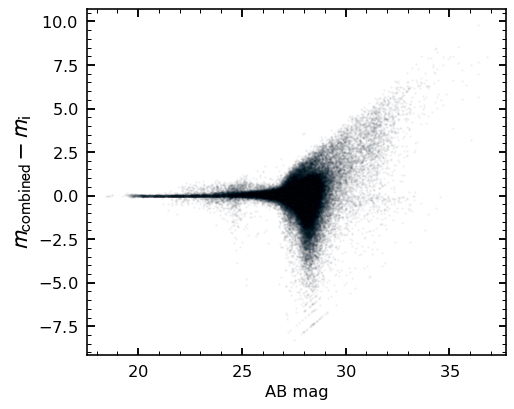

Text(0, 0.5, '$m_{\\rm combined} - m_{\\rm i}$')

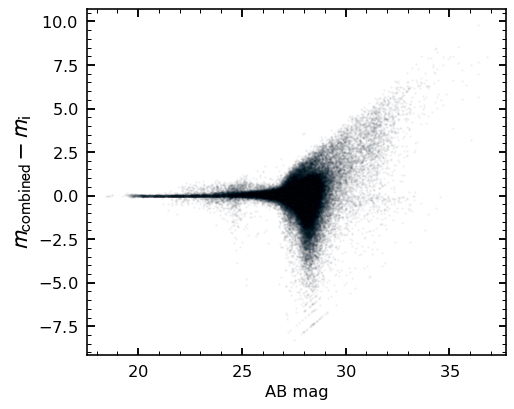

In [12]:
plt.scatter(cat['mag_ab_f106'], cat['mag_ab_f106'] - cat['mag_ab_f106_linegap5_1_0'], s=1, alpha=0.04)
plt.xlabel('AB mag')
plt.ylabel(r'$m_{\rm combined} - m_{\rm i}$', fontsize=20)
# plt.ylim(-0.6, 0.6)

In [195]:
crowd_cut = 0.5
sharp_cut = 0.02
snr_cut = 4
cat['good_flag'] = quality_cut(cat, snr=snr_cut, 
                               crowd={'f158': crowd_cut, 'f106': crowd_cut}, 
                               sharp={'f158': sharp_cut, 'f106': sharp_cut})
cat['star_flag'] = point_source_cut(cat, snr=snr_cut, 
                                    crowd={'f158': crowd_cut, 'f106': crowd_cut}, 
                                    sharp={'f158': sharp_cut, 'f106': sharp_cut})

In [196]:
np.sum(cat['star_flag']), np.sum(cat['good_flag'])

(np.int64(6817), np.int64(33012))

In [197]:
12342 / (7.5)**2

219.41333333333333

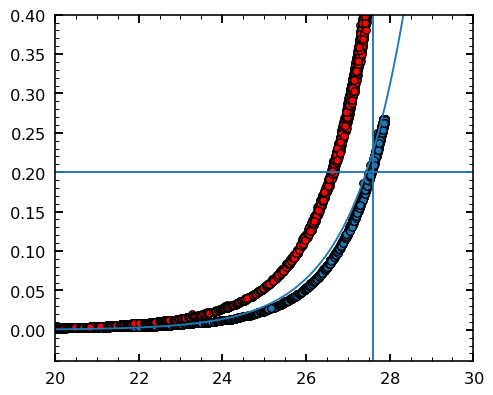

In [198]:
# plt.scatter(cat['mag_ab_f158_sub4_dither0'], cat['mag_err_f158_sub4_dither0'])
flag = cat['star_flag']
plt.scatter(cat['mag_ab_f158'][flag], cat['mag_err_f158'][flag])
# plt.scatter(cat['mag_ab_f158'], cat['mag_err_f158'], c=cat['obj_type'])
# plt.colorbar()

plt.scatter(cat['mag_ab_f158_linegap5_1_0'][flag], cat['mag_err_f158_linegap5_1_0'][flag], c='r')

mag = np.linspace(20, 29, 100)
plt.plot(mag, mag_uncertainty_func(mag, 0.33950503, -10.01496388))

plt.ylim(-0.04, 0.4)
plt.xlim(20, 30)
plt.axvline(27.6)
plt.axhline(1/5)

Text(0, 0.5, 'F158 [AB mag]')

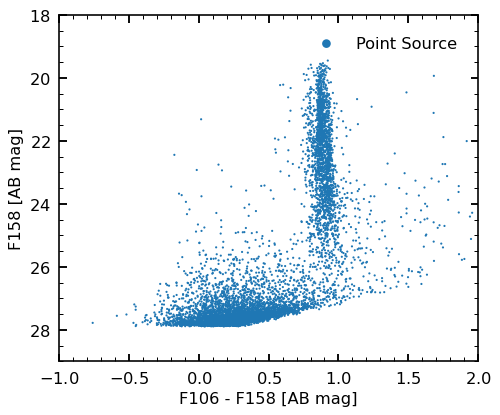

In [199]:
# plt.scatter(cat['mag_ab_f106'] - cat['mag_ab_f158'], cat['mag_ab_f158'],
#             ec='none', s=3, label='Dolphot all')

# flag = (cat['good_flag']) & (~cat['star_flag'])
# plt.scatter(cat[flag]['mag_ab_f106'] - cat[flag]['mag_ab_f158'], cat[flag]['mag_ab_f158'], 
#             ec='none', s=3, label='Dolphot Good')

flag = cat['star_flag']
plt.scatter(cat[flag]['mag_ab_f106'] - cat[flag]['mag_ab_f158'], cat[flag]['mag_ab_f158'], 
            ec='none', s=3, label='Point Source')

# plt.scatter(cat[flag]['mag_ab_f106_sub4_dither0'] - cat[flag]['mag_ab_f158_sub4_dither0'], cat[flag]['mag_ab_f158_sub4_dither0'], 
#             ec='none', s=3, label='Dolphot Single')

# plt.scatter(-2.5 * np.log10(truth_cat['F106'] / truth_cat['F158']), -2.5 * np.log10(truth_cat['F158']), 
#             fc='none', s=60, alpha=0.1)

# plt.scatter(ufd['MAG_F106'] - ufd['MAG_F158'], ufd['MAG_F158'], ec='none', s=3)

# dmod = 5 * np.log10(4) + 25
# flag = iso.eep <= 7

# filt1, filt2 = "F106", "F158"

# plt.plot((iso.mag_table[filt1] - iso.mag_table[filt2])[flag], 
#          iso.mag_table[filt2][flag] + dmod, 
#          c='darkviolet', lw=3, label='Isochrone')

# flag = iso.eep >= 7
# plt.scatter((iso.mag_table[filt1] - iso.mag_table[filt2])[flag], 
#          iso.mag_table[filt2][flag] + dmod, 
#          fc='darkviolet', ec='none', s=1)


plt.xlim(-1., 2)
plt.ylim(29, 18)
plt.xlim()
plt.legend(markerscale=4.0)
plt.xlabel('F106 - F158 [AB mag]')
plt.ylabel('F158 [AB mag]')

### Save catalog for UFD search

In [190]:
# cat.write('/scratch/gpfs/JENNYG/jiaxuanl/Data/Roman/UFD_detection/cena_3000s.ori.phot.csv', overwrite=True)

In [200]:
from ripples.utils import setup_dolphot_cat
Table(setup_dolphot_cat(cat, bands=['F106', 'F158'])).write(f'/scratch/gpfs/JENNYG/jiaxuanl/Data/Roman/UFD_detection/cena_3000s.phot.sharp{sharp_cut:.2f}.csv', overwrite=True)

In [201]:
sharp_cut

0.02

In [127]:
## Tile the background
from astropy.coordinates import SkyCoord, SkyOffsetFrame
def tile_catalog_radec(cat, tile_nx, tile_ny, 
                       ra_col='ra', dec_col='dec', center=None,
                       jitter_arcsec=0.0, seed=0):
    """
    Tile a small RA/Dec catalog into a larger footprint by repeating it on a TAN plane.

    Parameters
    ----------
    cat : astropy.table.Table (or dict-like with numpy arrays)
    tile_nx, tile_ny : int
        Number of tiles in x (roughly RA direction) and y (Dec direction).
        Total copies = tile_nx * tile_ny.
    center : (ra0, dec0) in degrees, optional
        Tangent point. If None, uses the median RA/Dec of the input catalog.
    jitter_arcsec : float
        Optional small random jitter applied to duplicated sources to hide seams.
    """
    rng = np.random.default_rng(seed)

    ra = np.array(cat[ra_col], dtype=float)
    dec = np.array(cat[dec_col], dtype=float)

    Lx_arcmin = (ra.max() - ra.min()) * np.cos(np.deg2rad(dec.mean())) * 60
    Ly_arcmin = (dec.max() - dec.min()) * 60
    print(Lx_arcmin, Ly_arcmin)

    if center is None:
        ra0 = np.median(ra)
        dec0 = np.median(dec)
    else:
        ra0, dec0 = center

    origin = SkyCoord(ra0*u.deg, dec0*u.deg, frame="icrs")
    off_frame = SkyOffsetFrame(origin=origin)

    c = SkyCoord(ra*u.deg, dec*u.deg, frame="icrs")
    c_off = c.transform_to(off_frame)

    # Local tangent-plane coordinates (small-angle offsets) in degrees
    x = c_off.lon.to_value(u.deg)   # "x" direction on plane
    y = c_off.lat.to_value(u.deg)   # "y" direction on plane

    Lx = (Lx_arcmin * u.arcmin).to_value(u.deg)
    Ly = (Ly_arcmin * u.arcmin).to_value(u.deg)

    # Build shifts: center tiles around (0,0)
    ix = np.arange(tile_nx) - (tile_nx - 1)/2
    iy = np.arange(tile_ny) - (tile_ny - 1)/2
    dx_grid, dy_grid = np.meshgrid(ix * Lx, iy * Ly, indexing="xy")
    dx_list = dx_grid.ravel()
    dy_list = dy_grid.ravel()

    # Replicate points
    x_big = np.concatenate([x + dx for dx in dx_list])
    y_big = np.concatenate([y + dy for dy in dy_list])

    if jitter_arcsec and jitter_arcsec > 0:
        sig = (jitter_arcsec * u.arcsec).to_value(u.deg)
        x_big += rng.normal(0.0, sig, size=x_big.size)
        y_big += rng.normal(0.0, sig, size=y_big.size)

    # Map back to RA/Dec
    c_big_off = SkyCoord(lon=x_big*u.deg, lat=y_big*u.deg, frame=off_frame)
    c_big = c_big_off.transform_to("icrs")

    ra_new = c_big.ra.wrap_at(360*u.deg).to_value(u.deg)
    dec_new = c_big.dec.to_value(u.deg)

    # Return a copy with updated coordinates
    out = cat.copy()
    # If you want to preserve other columns, replicate full rows:
    # (do this if cat is an astropy Table)
    try:
        out = np.repeat(cat, tile_nx*tile_ny)  # works for Table
    except Exception:
        pass

    out[ra_col] = ra_new
    out[dec_col] = dec_new
    return out

In [128]:
from ripples.utils import setup_dolphot_cat
cat_tile = Table(setup_dolphot_cat(tile_catalog_radec(cat, 3, 3)))

7.512092442912923 7.508390375221694


In [129]:
cat_tile.write(f'/scratch/gpfs/JENNYG/jiaxuanl/Data/Roman/UFD_detection/cena_3000s.phot.tile.sharp{sharp_cut:.2f}.csv', overwrite=True)

### Check star-galaxy separation very naiively

In [46]:
cat_ps = cat[cat['star_flag']]

In [47]:
true_cat = Table.read('/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/sky_jaguar_trilegal_cena/temp/sky_table_sky_jaguar_trilegal_cena.LINEGAP5_1.0.ecsv')
# true_cat = Table.read(f'/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/sky_jaguar_trilegal_cena/temp/sky_table_sky_jaguar_trilegal_cena_sizecut_642s.ecsv')
# true_cat = true_cat[true_cat['type'] == 'PSF']
out = xmatch_true_meas(true_cat, cat_ps, radius=0.4 * u.arcsec)

In [48]:
len(true_cat), len(out), len(cat_ps)

(67886, 16248, 16248)

(0.0, 1.1)

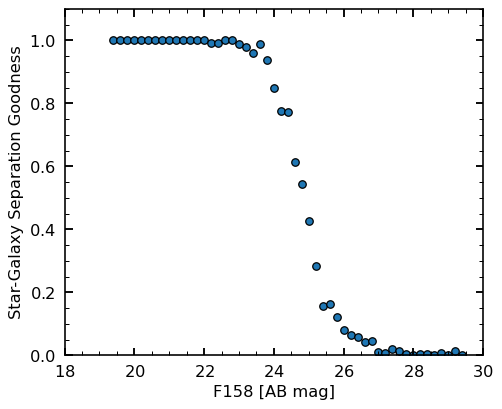

In [49]:
comp_bins = np.arange(17.5, 29.6, 0.2)
res = binned_statistic(-2.5 * np.log10(out['true_F158']), 
                       out['true_type'] == 'PSF', 
                       bins=comp_bins, 
                       statistic='mean')
mag, comp = 0.5 * (res.bin_edges[:-1] + res.bin_edges[1:]), res.statistic
plt.scatter(mag, comp)

plt.ylabel('Star-Galaxy Separation Goodness')
plt.xlabel('F158 [AB mag]')

plt.xlim(18, 30)
plt.ylim(0, 1.1)

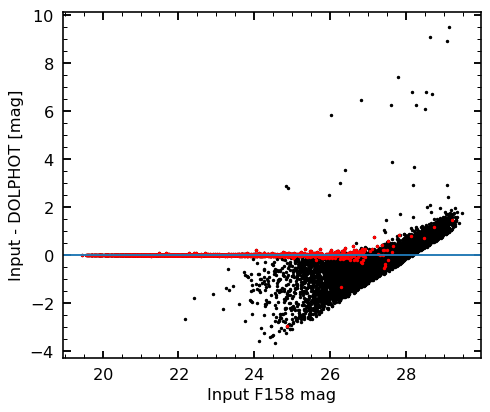

In [50]:
plt.scatter(-2.5 * np.log10(out['true_F158']), -2.5 * np.log10(out['true_F158']) - out['meas_mag_ab_f158'], s=3, color='k')

flag = out['true_type'] == 'PSF'
plt.scatter(-2.5 * np.log10(out[flag]['true_F158']), 
            -2.5 * np.log10(out[flag]['true_F158']) - out[flag]['meas_mag_ab_f158'], s=3, color='r')

# plt.ylim(-0.4, 0.4)

plt.xlabel('Input F158 mag')
plt.ylabel('Input - DOLPHOT [mag]')
plt.axhline(0)

## 3. Artificial Star Tests to derive completeness and photometric uncertainties

We use a function `quality_cut` to cull the catalog. If the `good_flag` is true, it passes the QA criteria in the `quality_cut` function. See here for more information on QA cuts: https://dolphot-jwst.readthedocs.io/en/latest/post-processing/catalogs.html

We also assume that the oc

In [149]:
from rosesim.utils import read_dolphot_cat, delta_m_scatter_vs_mag, logistic_completeness, mag_uncertainty_func, fit_logistic_completeness
from rosesim.utils import read_dolphot_cat, xmatch_true_meas
from rosesim import Roman_zp_AB_Vega_parsec

def quality_cut(cat, snr=5, crowd={'f158': 0.5, 'f106': 0.5}, sharp={'f158': 0.03, 'f106': 0.03}):
    flag = cat['snr_f106'] > snr
    flag &= cat['snr_f158'] > snr
    flag &= (cat['crowd_f106'] < crowd['f106'])
    flag &= (cat['crowd_f158'] < crowd['f158'])
    flag &= (cat['qflag_f158'] <= 4)
    flag &= (cat['qflag_f106'] <= 4)
    flag &= (cat['obj_type'] <= 2) # (1=bright star, 2=faint, 3=elongated, 4=hot pixel, 5=extended)
    flag &= (cat['pass_det'] < 3)
    return flag


def point_source_cut(cat, snr=5, crowd={'f158': 0.5, 'f106': 0.5}, sharp={'f158': 0.03, 'f106': 0.03}):
    flag = quality_cut(cat, snr=snr, crowd=crowd, sharp=sharp)
    flag &= (cat['sharp_f106']**2 < sharp['f106'])
    flag &= (cat['sharp_f158']**2 < sharp['f158'])
    flag &= (cat['chi_f106'] < 3)
    flag &= (cat['chi_f158'] < 3) # this is tbd
    return flag

In [202]:
# Here we load the AST output catalog,
exptime = 3000
# fake = read_dolphot_cat(f'./{host}_{exptime}s/fake_n253_{exptime}s.fake', f'./{host}_{exptime}s.phot.columns', fake=True)
fake = read_dolphot_cat(f'./fake_cena_{exptime}s.fake', f'./{host}_{exptime}s.phot.columns', fake=True)

crowd_cut = 0.5
# sharp_cut = 0.04
sharp_cut = 0.02

# We apply QA cuts
snr_cut = 4
fake['star_flag'] = point_source_cut(fake, snr=snr_cut, 
                                     crowd={'f158': crowd_cut, 'f106': crowd_cut}, 
                                     sharp={'f158': sharp_cut, 'f106': sharp_cut})
fake['good_flag'] = quality_cut(fake, snr=snr_cut, 
                               crowd={'f158': crowd_cut, 'f106': crowd_cut}, 
                               sharp={'f158': sharp_cut, 'f106': sharp_cut})

len(fake)

Filters: ['F106', 'F158']


tag_filter_combos [('LINEGAP5_1.0', 'F106'), ('LINEGAP5_1.1', 'F106'), ('LINEGAP5_1.2', 'F106'), ('LINEGAP5_1.3', 'F106'), ('LINEGAP5_1.4', 'F106'), ('LINEGAP5_1.0', 'F158'), ('LINEGAP5_1.1', 'F158'), ('LINEGAP5_1.2', 'F158'), ('LINEGAP5_1.3', 'F158'), ('LINEGAP5_1.4', 'F158')]
Converting counts_true_f106_linegap5_1_0 to mag_true_f106_linegap5_1_0
Converting counts_true_f106_linegap5_1_1 to mag_true_f106_linegap5_1_1
Converting counts_true_f106_linegap5_1_2 to mag_true_f106_linegap5_1_2
Converting counts_true_f106_linegap5_1_3 to mag_true_f106_linegap5_1_3
Converting counts_true_f106_linegap5_1_4 to mag_true_f106_linegap5_1_4
Converting counts_true_f158_linegap5_1_0 to mag_true_f158_linegap5_1_0
Converting counts_true_f158_linegap5_1_1 to mag_true_f158_linegap5_1_1
Converting counts_true_f158_linegap5_1_2 to mag_true_f158_linegap5_1_2
Converting counts_true_f158_linegap5_1_3 to mag_true_f158_linegap5_1_3
Converting counts_true_f158_linegap5_1_4 to mag_true_f158_linegap5_1_4


10309

(-0.1, 1.0)

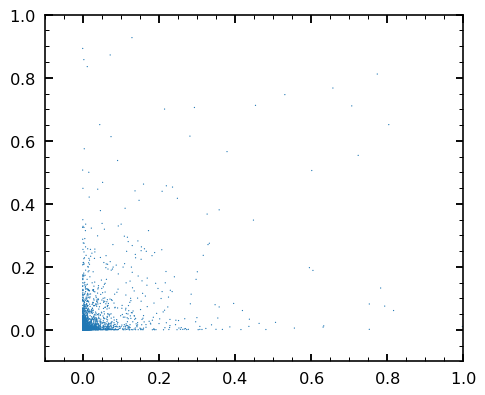

In [203]:
plt.scatter(fake['sharp_f106']**2, fake['sharp_f158']**2, s=1, ec='none')
plt.xlim(-0.1, 1)
plt.ylim(-0.1, 1)

In [182]:
# input mags are in Vega

### 3.1 Completeness

In [204]:
# fake['good_flag'] = quality_cut(fake, snr=3, crowd={'f158': 0.5, 'f106': 0.5}, sharp={'f158': 0.03, 'f106': 0.03}) 

Best fit completeness for f106: 27.26529651705816 0.5171017415160261
Best fit completeness for f158: 26.887640777415474 0.48981588619441563


Text(0.5, 1.0, 'High Galactic Latitude Field (NGC 253)')

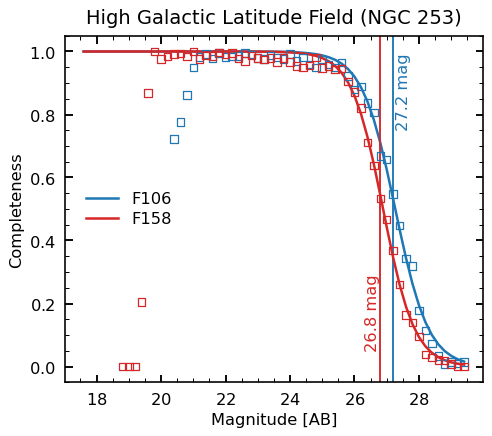

In [205]:
comp_bins = np.arange(17.5, 29.6, 0.2)
mag_50_dict = {}
colors = {'f106': 'C0', 'f158': 'C3'}
tag = 'linegap5_1_0'

filt = 'f106'
res = binned_statistic(fake[f'mag_true_{filt}_{tag}'], (np.isfinite(fake[f'mag_ab_{filt}']) & fake['star_flag']), bins=comp_bins, statistic='mean')
mag, comp = 0.5 * (res.bin_edges[:-1] + res.bin_edges[1:]), res.statistic
plt.scatter(mag, comp, marker='s', fc='none', ec=colors[filt], zorder=10)
print(f'Best fit completeness for {filt}:', *fit_logistic_completeness(mag, comp)[0])
comp_pred = logistic_completeness(mag, *fit_logistic_completeness(mag, comp)[0])
mag_50_dict[filt] = mag[np.argmin(abs(comp_pred - 0.5))]
plt.plot(mag, comp_pred, label=filt.upper(), lw=2, c=colors[filt])
plt.axvline(mag_50_dict[filt], c=colors[filt])
plt.text(mag_50_dict[filt]+0.1, 0.75, f'{mag_50_dict[filt]:.1f} mag', c=colors[filt], rotation=90, ha='left', va='bottom')


filt = 'f158'
res = binned_statistic(fake[f'mag_true_{filt}_{tag}'], (np.isfinite(fake[f'mag_ab_{filt}']) & fake['star_flag']), bins=comp_bins, statistic='mean')
mag, comp = 0.5 * (res.bin_edges[:-1] + res.bin_edges[1:]), res.statistic
plt.scatter(mag, comp, marker='s', fc='none', ec=colors[filt], zorder=10)
print(f'Best fit completeness for {filt}:', *fit_logistic_completeness(mag, comp)[0])
comp_pred = logistic_completeness(mag, *fit_logistic_completeness(mag, comp)[0])
mag_50_dict[filt] = mag[np.argmin(abs(comp_pred - 0.5))]
plt.plot(mag, comp_pred, label=filt.upper(), lw=2, c=colors[filt])
plt.axvline(mag_50_dict[filt], c=colors[filt])
plt.text(mag_50_dict[filt], 0.05, f'{mag_50_dict[filt]:.1f} mag', c=colors[filt], rotation=90, ha='right', va='bottom')

plt.legend()
plt.xlabel('Magnitude [AB]')
plt.ylabel('Completeness')
plt.title('High Galactic Latitude Field (NGC 253)')

### 3.2 Photometric uncertainty

Best fit in f106 : [ 0.33626276 -9.9201653 ]
Best fit in f158 : [  0.34290294 -10.01450665]

Photometric uncertainty dict:
{'f106': array([ 0.33626276, -9.9201653 ]), 'f158': array([  0.34290294, -10.01450665])}


(20.0, 29.0)

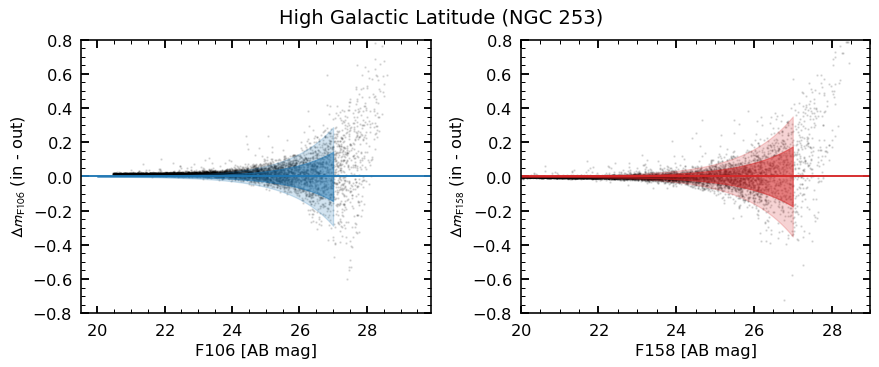

In [206]:
bands = ['f106', 'f158']
fig, axes = plt.subplots(1, len(bands), figsize=(10, 4))
tag = 'linegap5_1_0'

coeffs_dict = {}

fake_good = fake[fake['star_flag']]

for i, filt in enumerate(bands):
    # Fit for a relation between mag and mag_err
    delta_m = fake_good[f'mag_true_{filt}_{tag}'] - fake_good[f'mag_ab_{filt}']
    mag_bins = np.arange(23.0, 27, 0.3)
    scatter_tab = delta_m_scatter_vs_mag(
        fake_good[f'mag_true_{filt}_{tag}'], delta_m,
        mag_bins=mag_bins, clip_sigma=3.0,
        clip_iters=3, method="mad", min_per_bin=20,
    )
    flag = (scatter_tab['mag_center'] <= 27) & ~np.isnan(scatter_tab['scatter'])
    coeffs_dict[filt] = np.polyfit(scatter_tab['mag_center'][flag], np.log10(scatter_tab['scatter'][flag]), 1)
    print(f'Best fit in {filt} :', coeffs_dict[filt])

    plt.sca(axes[i])
    plt.scatter(fake_good[f'mag_true_{filt}_{tag}'], delta_m,  s=1, c='k', alpha=0.1)
    _x = np.linspace(20, 27, 100)
    sigma_pred = 10**(coeffs_dict[filt][0] * _x + coeffs_dict[filt][1])
    plt.fill_between(_x, sigma_pred, -sigma_pred, alpha=0.5, color=colors[filt])
    plt.fill_between(_x, sigma_pred * 2, -sigma_pred * 2, alpha=0.2, color=colors[filt])
    plt.axhline(0, color=colors[filt])
    plt.ylim(-0.8, 0.8)
    # plt.ylim(-0.1, 0.1)
    plt.xlabel(f'{filt.upper()} [AB mag]')
    plt.ylabel(r'$\Delta m_{\rm ' + filt.upper() + '}$ (in - out)')

plt.tight_layout()
plt.suptitle('High Galactic Latitude (NGC 253)', y=1.02)
print('\nPhotometric uncertainty dict:')
print(coeffs_dict)

plt.xlim(20, 29)


In [209]:
10 / 1e6 / 3.5 * 206265

0.5893285714285714

## Compile the whole thing

Text(0.5, 1.04, 'Cen A (High Galactic Latitutde), IM_600_16, 5 exposures')

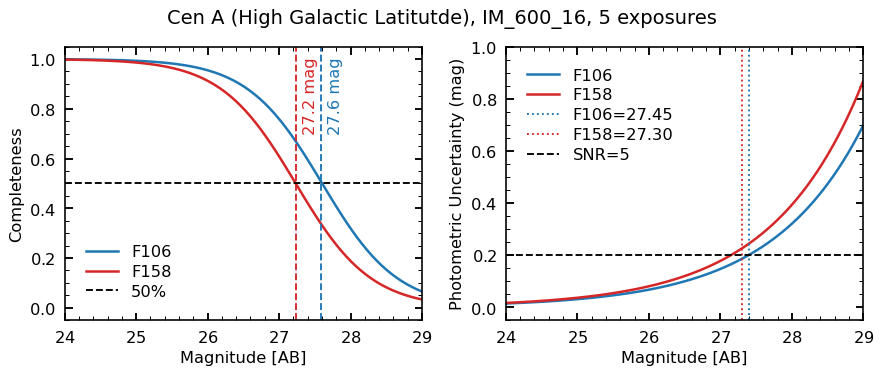

In [128]:
completeness_dict = {'F106': [27.602552363735068, 0.5251360606113693], 
                     'F158': [27.232389090274577, 0.5253926723598782]} # 5x IM_600_16
mag_uncertainty_dict = {'F106': [ 0.33868952, -9.97805577], 
                        'F158': [ 0.34465689, -10.0563257]} #  DOLPHOT

fig, [ax1, ax2] = plt.subplots(1, 2, figsize=(10, 4))

plt.sca(ax1)
mag = np.linspace(22, 29, 100)
plt.plot(mag, logistic_completeness(mag, *completeness_dict['F106']), label='F106', color=colors['f106'], lw=2)
plt.plot(mag, logistic_completeness(mag, *completeness_dict['F158']), label='F158', color=colors['f158'], lw=2)

comp_pred = logistic_completeness(mag, *completeness_dict['F106'])
mag_50 = mag[np.argmin(abs(comp_pred - 0.5))]
plt.axvline(mag_50, c=colors['f106'], ls='--')
plt.text(mag_50+0.1, 0.7, f'{mag_50:.1f} mag', c=colors['f106'], rotation=90, ha='left', va='bottom')

comp_pred = logistic_completeness(mag, *completeness_dict['F158'])
mag_50 = mag[np.argmin(abs(comp_pred - 0.5))]
plt.axvline(mag_50, c=colors['f158'], ls='--')
plt.text(mag_50+0.1, 0.7, f'{mag_50:.1f} mag', c=colors['f158'], rotation=90, ha='left', va='bottom')

plt.axhline(0.5, ls='--', label='50%', c='k')
plt.xlim(24, 29)
plt.legend()
plt.xlabel('Magnitude [AB]')
plt.ylabel('Completeness')
plt.ylim(-0.05, 1.05)

plt.sca(ax2)
plt.plot(mag, mag_uncertainty_func(mag, *mag_uncertainty_dict['F106']), label='F106', c=colors['f106'], lw=2)
plt.plot(mag, mag_uncertainty_func(mag, *mag_uncertainty_dict['F158']), label='F158', c=colors['f158'], lw=2)
plt.axvline(27.4, color=colors['f106'], label='F106=27.45', ls=':')
plt.axvline(27.3, color=colors['f158'], label='F158=27.30', ls=':')
plt.axhline(0.2, ls='--', label='SNR=5', c='k')

plt.xlim(24, 29)
plt.legend()
plt.xlabel('Magnitude [AB]')
plt.ylabel('Photometric Uncertainty (mag)')
plt.ylim(-0.05, 1)

plt.tight_layout()
plt.suptitle('Cen A (High Galactic Latitutde), IM_600_16, 5 exposures', y=1.04)